# 1. Objetivo del Proyecto

El objetivo principal de este proyecto fue desarrollar un modelo de Machine Learning capaz de predecir la ocurrencia de lluvia al día siguiente (*RainTomorrow*) utilizando información meteorológica histórica. Para ello, se realizó un proceso completo de Ciencia de Datos que incluyó la exploración y limpieza de los datos, el análisis exploratorio, la selección y transformación de variables, el entrenamiento de múltiples modelos de clasificación y la evaluación comparativa de su desempeño.

Inicialmente se consideró la utilización de bases de datos meteorológicas argentinas; sin embargo, las fuentes disponibles presentaban una cantidad limitada de variables observadas, lo que restringía significativamente el potencial predictivo de los modelos. Debido a esta limitación, se optó por trabajar con una base de datos internacional más completa, que incorpora una mayor variedad de mediciones atmosféricas y permite estudiar relaciones más complejas entre las condiciones climáticas actuales y la ocurrencia de precipitaciones futuras.

A lo largo del proyecto se buscó no solo obtener un modelo con buen desempeño predictivo, sino también comprender qué variables aportan mayor información al problema y analizar la posibilidad de trasladar este tipo de soluciones a contextos donde la disponibilidad de datos meteorológicos es más reducida.


In [15]:
from pathlib import Path
import pandas as pd

# Raíz del proyecto
PROJECT_ROOT = Path("../../data/")

# Carpeta de resultados
RESULTS_DIR = PROJECT_ROOT / "results"


print(RESULTS_DIR.resolve())

C:\Users\lauta\Desktop\DataScience\ds_proyecto\data\results


# 2. Resumen de Resultados

Se evaluaron diferentes algoritmos de clasificación con el objetivo de predecir la variable objetivo *RainTomorrow*. Cada modelo fue entrenado y validado utilizando los mismos conjuntos de datos y métricas de evaluación para garantizar una comparación justa entre alternativas.

Los modelos analizados incluyeron Regresión Logística, Random Forest, XGBoost y Support Vector Machine (SVM). Posteriormente, se aplicó ajuste de hiperparámetros y validación cruzada estratificada para mejorar la robustez de los resultados obtenidos.

La comparación de métricas mostró que el modelo SVM optimizado alcanzó el mejor equilibrio entre capacidad predictiva y estabilidad general, obteniendo los valores más consistentes en las métricas de clasificación evaluadas. Este comportamiento sugiere una adecuada capacidad de generalización frente a datos no observados durante el entrenamiento.

Los resultados obtenidos demuestran que la información meteorológica disponible contiene patrones suficientes para anticipar la ocurrencia de precipitaciones futuras con un nivel de precisión satisfactorio, validando el uso de técnicas de Machine Learning como herramientas de apoyo para la toma de decisiones basadas en datos climáticos.


In [32]:
results_df = pd.read_csv(
    RESULTS_DIR / "model_comparison.csv"
)

display(
    results_df.style
    .background_gradient(
        cmap="Blues",
        subset=["ROC_AUC"]
    )
    .format({
        "ROC_AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,LogisticRegression,0.772210,0.732984,0.740741,0.736842,0.8628
1,SVM,0.799544,0.756345,0.788360,0.772021,0.8799
2,XGBoost,0.790433,0.756614,0.756614,0.756614,0.8590


### Análisis de Errores

Si bien el modelo seleccionado obtuvo el mejor desempeño general entre las alternativas evaluadas, ningún sistema predictivo está exento de errores. Por este motivo, resulta importante analizar la naturaleza de las predicciones incorrectas.

La matriz de confusión permite identificar dos tipos principales de error:

* **Falsos Positivos:** el modelo predice lluvia cuando finalmente no ocurre.
* **Falsos Negativos:** el modelo predice ausencia de lluvia cuando efectivamente llueve.

Desde una perspectiva práctica, los falsos negativos suelen representar el error más costoso, ya que implican no anticipar un evento de precipitación que realmente ocurre. Dependiendo del contexto de aplicación, este tipo de error podría afectar actividades agrícolas, logísticas o de planificación urbana.

El análisis de la matriz de confusión muestra que el modelo mantiene una capacidad adecuada para identificar eventos de lluvia y ausencia de precipitaciones. Se observa además una distribución equilibrada entre falsos positivos y falsos negativos, lo que sugiere que el modelo no presenta una tendencia marcada a sobreestimar o subestimar la ocurrencia de lluvias.

A pesar de este desempeño favorable, continúan existiendo observaciones difíciles de clasificar debido a la naturaleza compleja de los fenómenos meteorológicos. Factores atmosféricos no registrados en el conjunto de datos o variaciones locales de las condiciones climáticas pueden contribuir a estos errores de predicción.

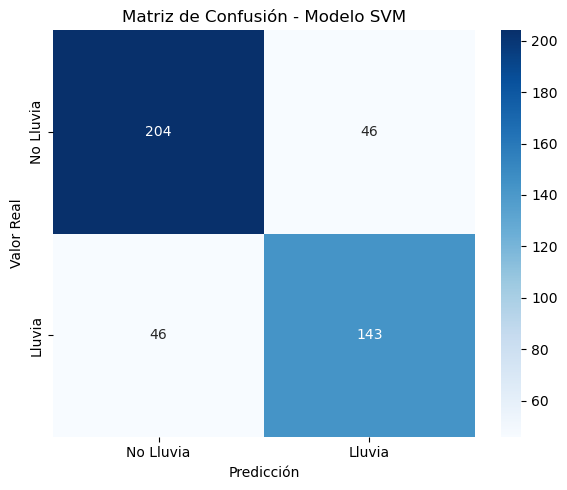

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

pred_df = pd.read_csv(
    RESULTS_DIR / "svm_predictions.csv"
)

cm = confusion_matrix(
    pred_df["Actual"],
    pred_df["Predicted"]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Lluvia", "Lluvia"],
    yticklabels=["No Lluvia", "Lluvia"],
    cbar=True
)

plt.title("Matriz de Confusión - Modelo SVM")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.tight_layout()
plt.show()

# 3. Aplicaciones Prácticas del Modelo

La capacidad de anticipar la ocurrencia de precipitaciones posee aplicaciones directas en múltiples sectores económicos y sociales. Aunque el modelo desarrollado en este proyecto tiene fines académicos, los resultados obtenidos permiten visualizar escenarios reales donde una herramienta de este tipo podría aportar valor mediante la mejora en la planificación y la toma de decisiones.

La predicción temprana de lluvias permite transformar datos meteorológicos en información accionable, facilitando la reducción de riesgos operativos y optimizando el uso de recursos disponibles.


## Agricultura y Producción Rural

Uno de los sectores que más podría beneficiarse de un sistema de predicción de precipitaciones es la actividad agrícola. La información anticipada sobre posibles eventos de lluvia permite optimizar decisiones relacionadas con el riego, la aplicación de fertilizantes, el uso de maquinaria y la planificación de cosechas. Además, en regiones con alta dependencia de la producción agropecuaria, este tipo de herramientas podría integrarse a plataformas de monitoreo climático para mejorar la eficiencia en la gestión de recursos.

## Transporte y Logística

Las condiciones meteorológicas influyen significativamente sobre la operación de sistemas de transporte terrestre, aéreo y marítimo. La ocurrencia de precipitaciones puede afectar la seguridad vial, aumentar los tiempos de traslado y modificar cronogramas operativos. La incorporación de sistemas predictivos en procesos logísticos resulta especialmente relevante en actividades sensibles a retrasos, como el transporte de productos perecederos o la distribución de mercancías a gran escala.

## Gestión Pública y Prevención de Riesgos

Los organismos responsables de la gestión urbana y los servicios de emergencia pueden beneficiarse significativamente de herramientas de predicción meteorológica. La anticipación de eventos de lluvia permite coordinar acciones preventivas, optimizar la utilización de recursos y mejorar los tiempos de respuesta ante posibles contingencias. Entre las aplicaciones potenciales se incluyen la gestión de sistemas de drenaje urbano, la planificación de tareas de mantenimiento, la emisión de alertas tempranas y el monitoreo de zonas con riesgo de inundación.

# 4. Transferencia del Modelo y Limitaciones de los Datos

Uno de los objetivos iniciales de este proyecto consistía en desarrollar un sistema de predicción meteorológica utilizando información proveniente de estaciones climáticas argentinas. Sin embargo, durante la etapa de búsqueda y evaluación de fuentes de datos se identificaron importantes limitaciones relacionadas con la disponibilidad y diversidad de variables meteorológicas registradas.

Debido a estas restricciones, se optó por utilizar una base de datos internacional más completa, la cual incorpora una mayor cantidad de observaciones atmosféricas y permite capturar relaciones más complejas entre las condiciones climáticas actuales y la ocurrencia de precipitaciones futuras.

| Característica | Dataset Internacional | Dataset Argentino |
|---------------|----------------------|------------------|
| Cantidad de Variables | Alta | Baja |
| Variables Atmosféricas | Amplias | Limitadas |
| Información de Nubosidad | Sí | No disponible |
| Franja temporal disponible | Muy Amplia | Limitada |
| Humedad en distintos horarios | Sí | Parcial |
| Potencial Predictivo | Alto | Moderado |

## Reflexión sobre la Calidad de los Datos

Los resultados obtenidos durante el desarrollo del proyecto sugieren que la calidad y diversidad de los datos disponibles constituyen factores determinantes para el éxito de un sistema predictivo.

Si bien la selección y optimización de algoritmos permitió obtener mejoras en el desempeño, el principal factor diferenciador estuvo asociado a la riqueza de las variables observadas. Esto refuerza una de las premisas fundamentales de la Ciencia de Datos: modelos complejos difícilmente pueden compensar la ausencia de información relevante en los datos de entrada.

Por este motivo, futuras iniciativas orientadas a la predicción meteorológica podrían beneficiarse significativamente de estrategias de recolección más completas y estandarizadas, incluso antes de incorporar algoritmos más sofisticados.


# 5. Variables Relevantes y Recomendaciones para la Recolección de Datos

Con el objetivo de comprender qué factores aportan mayor información al problema de predicción, se realizó un análisis de importancia de variables utilizando un modelo Random Forest. Este enfoque permite estimar la contribución relativa de cada característica al proceso de decisión del modelo.

Los resultados mostraron que variables relacionadas con precipitaciones previas, humedad relativa, temperatura, presión atmosférica y velocidad del viento presentan una influencia significativa sobre la predicción de lluvias futuras.

Particularmente, la variable **SNOW** (cantidad de nieve registrada) apareció como la característica de mayor importancia dentro del conjunto analizado. Sin embargo, este resultado debe interpretarse considerando las características geográficas del dataset utilizado. En regiones donde las precipitaciones en forma de nieve son frecuentes, esta variable puede aportar información valiosa sobre determinadas condiciones atmosféricas.

No obstante, en gran parte del territorio argentino —especialmente en regiones de clima cálido o subtropical— la ocurrencia de nieve es extremadamente poco frecuente o inexistente. Por este motivo, la utilidad práctica de esta variable resulta limitada para aplicaciones locales y no debería considerarse un requisito prioritario para sistemas de monitoreo meteorológico destinados a dichas zonas.

Excluyendo esta particularidad, las variables asociadas a humedad relativa, temperatura, presión atmosférica y velocidad del viento emergen como los factores más consistentes y potencialmente transferibles a diferentes regiones geográficas.

A partir de estos resultados, se recomienda que futuros sistemas de recolección meteorológica prioricen el registro sistemático de:

* Humedad relativa.
* Temperatura máxima y mínima.
* Presión atmosférica.
* Velocidad y dirección del viento.
* Precipitaciones registradas.
* Variables asociadas a nubosidad y radiación solar.

La incorporación y estandarización de estas mediciones permitiría construir modelos predictivos más robustos y adaptables a distintos contextos climáticos, mejorando la capacidad de anticipar eventos de precipitación y fortaleciendo el potencial de aplicación de herramientas basadas en aprendizaje automático.


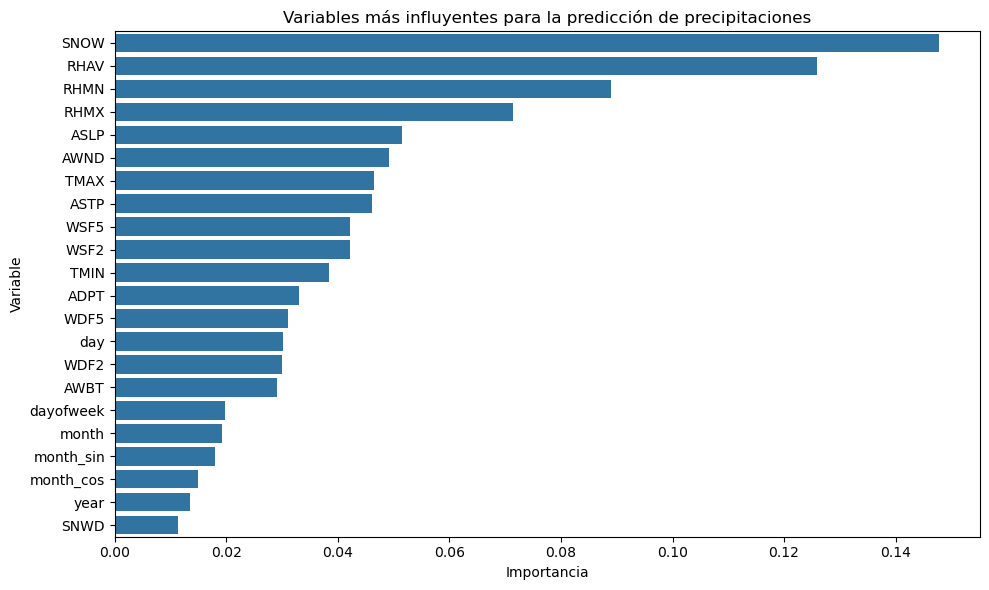

In [47]:
# Carga
df = pd.read_csv("../../data/processed/weather_processed_WITHSNOW.csv")

X = df.drop(columns=["Rain"])
y = df["Rain"]

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=importances.values,
    y=importances.index
)

plt.title("Variables más influyentes para la predicción de precipitaciones")
plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

# 6. Conclusiones Finales

El proyecto permitió desarrollar y evaluar un sistema de predicción de precipitaciones basado en técnicas de Machine Learning, recorriendo todas las etapas fundamentales de un flujo de trabajo de Ciencia de Datos: obtención y preparación de datos, análisis exploratorio, ingeniería de variables, entrenamiento de modelos y evaluación de desempeño.

Entre los algoritmos analizados, el modelo Support Vector Machine (SVM) optimizado obtuvo los mejores resultados generales, alcanzando el mayor equilibrio entre precisión, sensibilidad y capacidad de discriminación. Los resultados obtenidos demuestran que es posible anticipar la ocurrencia de precipitaciones con un nivel de desempeño satisfactorio utilizando únicamente información meteorológica histórica.

Más allá de la comparación entre modelos, uno de los hallazgos más relevantes del proyecto estuvo relacionado con la importancia de la calidad y diversidad de los datos disponibles. La necesidad de recurrir a una fuente internacional debido a las limitaciones encontradas en bases de datos locales puso de manifiesto que la disponibilidad de información suele representar un factor tan importante como la elección del algoritmo utilizado. Asimismo, el análisis de importancia de variables mostró que factores asociados a humedad, temperatura, presión atmosférica y viento poseen una influencia significativa sobre la ocurrencia de precipitaciones, proporcionando información valiosa para el diseño de futuros sistemas de monitoreo meteorológico.